In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report
from tabulate import tabulate


In [5]:
def train_SVM_model(C_constant, X_train, y_train, X_test, y_test):
    """
    Trains an SVM model with the given C value, normalizes the data, and evaluates performance.

    Parameters:
    - C_constant: Regularization parameter for the SVM
    - X_train, y_train: Training data
    - X_test, y_test: Test data
    - class_labels: Optional, labels for the confusion matrix

    Returns:
    - Dictionary with accuracy, sensitivity, specificity, and F1 score
    """

    # Define SVM pipeline with normalization
    svm_pipeline = Pipeline([
        ('normalizer', Normalizer()),
        ('svm', SVC(C=C_constant, kernel='rbf'))
    ])

    # Train the model
    svm_pipeline.fit(X_train, y_train)

    # Test prediction
    y_pred = svm_pipeline.predict(X_test)

    # Compute Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Robot1', 'Robot2', 'Robot3', 'Robot4', 'Robot5'],
                yticklabels=['Robot1', 'Robot2', 'Robot3', 'Robot4', 'Robot5'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"SVM (C: {C_constant}) - Confusion Matrix")
    plt.show()

    # Accuracy Score
    accuracy = accuracy_score(y_test, y_pred)

    # Sensitivity (Macro Recall)
    sensitivity = recall_score(y_test, y_pred, average='macro')

    # F1 Score Calculation
    f1 = f1_score(y_test, y_pred, average='macro')

    # Specificity Calculation
    specificity_list = []
    for i in range(len(conf_matrix)):
        tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
        fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_list.append(specificity)
    specificity = np.mean(specificity_list)

    # Print Results
    print(f"\nSVM Model (C = {C_constant}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity (Macro Recall): {sensitivity:.4f}")
    print(f"Specificity (Macro Specificity): {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import Normalizer
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report
from scipy.stats import mode
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

def map_reduce_svm(chunk_num: int, X_train_scaled, y_train, X_test_scaled, y_test, C_constant=1000000):
    """
    Implements Map-Reduce SVM for large datasets:
    - Divides training data into `chunk_num` partitions.
    - Trains an SVM model on each chunk.
    - Aggregates predictions using majority voting.
    - Computes confusion matrix and evaluation metrics.

    Parameters:
    - chunk_num: Number of data partitions.
    - X_train_scaled, y_train: Training data.
    - X_test_scaled, y_test: Test data.
    - C_constant: Regularization parameter for SVM.

    Returns:
    - Dictionary containing accuracy, sensitivity, specificity, and F1-score.
    """
    chunk_size = ceil(len(X_train_scaled) / chunk_num)
    predictions = []

    # Train SVM models on different chunks and store predictions
    for i in range(chunk_num):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, len(X_train_scaled))

        X_chunk = X_train_scaled[start_idx:end_idx]
        y_chunk = y_train[start_idx:end_idx]

        if len(X_chunk) == 0:
            continue  # Skip empty chunks

        # Train SVM model
        svm = Pipeline([
            ('normalizer', Normalizer()),
            ('svm', SVC(C=C_constant, kernel='rbf'))
        ])
        svm.fit(X_chunk, y_chunk)

        # Store predictions
        predictions.append(svm.predict(X_test_scaled))

    if not predictions:
        raise ValueError("No models were trained. Check your dataset and chunking process.")

    # Majority voting
    final_predictions = mode(np.array(predictions), keepdims=False).mode

    # Compute Confusion Matrix
    conf_matrix = confusion_matrix(y_test, final_predictions)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"SVM (C={C_constant}) - Confusion Matrix")
    plt.show()

    # Compute metrics
    accuracy = accuracy_score(y_test, final_predictions)
    sensitivity = recall_score(y_test, final_predictions, average='macro')
    f1 = f1_score(y_test, final_predictions, average='macro')

    # Compute specificity for multiclass classification
    specificity = np.mean([
        (conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])) /
        (conf_matrix.sum() - conf_matrix[:, i].sum()) if (conf_matrix.sum() - conf_matrix[:, i].sum()) > 0 else 0
        for i in range(len(conf_matrix))
    ])

    print("\nClassification Report:\n", classification_report(y_test, final_predictions))

    return {
        "Chunk Number": chunk_num,
        "C": C_constant,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1 Score": f1
    }


In [7]:
# Load dataset
robot_df = pd.read_csv("Classification_of_Robots_from_their_conversation_sequence.csv")

# Drop missing values
robot_df = robot_df.dropna()

# Separate features (X) and target variable (y)
X = robot_df.iloc[:, 1:]  # Features: Assume columns 1 onward are numerical features
y = robot_df.iloc[:, 0]   # Target: First column is 'robotID'

# Encode target variable (convert labels to numeric format)
y = y.astype(str).apply(lambda x: f"Robot{x}")  # Add "Robot" prefix to labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Normalize features (MinMaxScaler scales between 0 and 1)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


[[18505   158    29  1308     0]
 [   54    10     0 19936     0]
 [   31    10 19941    15     3]
 [   49     3     0 19948     0]
 [    0     0     0     0 20000]]


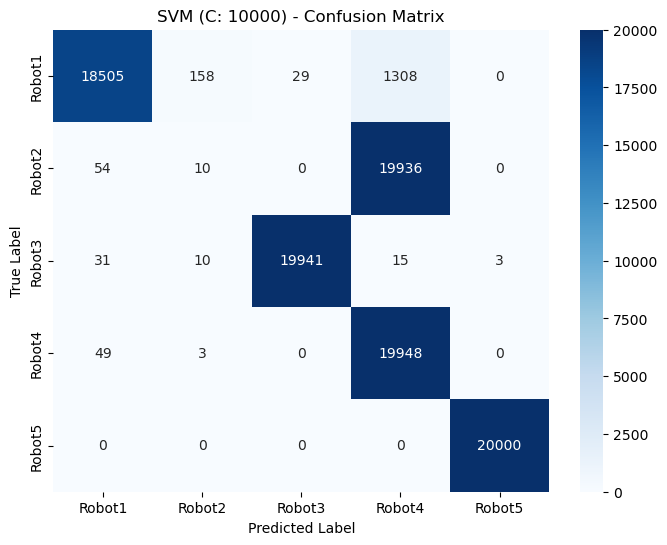


SVM Model (C = 10000):
Accuracy: 0.7840
Sensitivity (Macro Recall): 0.7840
Specificity (Macro Specificity): 0.9460
F1 Score: 0.7217

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96     20000
           1       0.06      0.00      0.00     20000
           2       1.00      1.00      1.00     20000
           3       0.48      1.00      0.65     20000
           4       1.00      1.00      1.00     20000

    accuracy                           0.78    100000
   macro avg       0.71      0.78      0.72    100000
weighted avg       0.71      0.78      0.72    100000



In [10]:
train_SVM_model(10000, X_train_scaled, y_train, X_test_scaled, y_test)

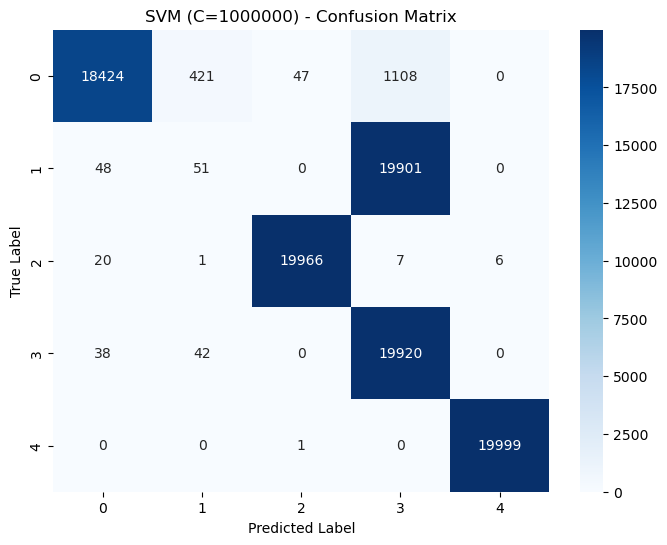


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.96     20000
           1       0.10      0.00      0.00     20000
           2       1.00      1.00      1.00     20000
           3       0.49      1.00      0.65     20000
           4       1.00      1.00      1.00     20000

    accuracy                           0.78    100000
   macro avg       0.72      0.78      0.72    100000
weighted avg       0.72      0.78      0.72    100000



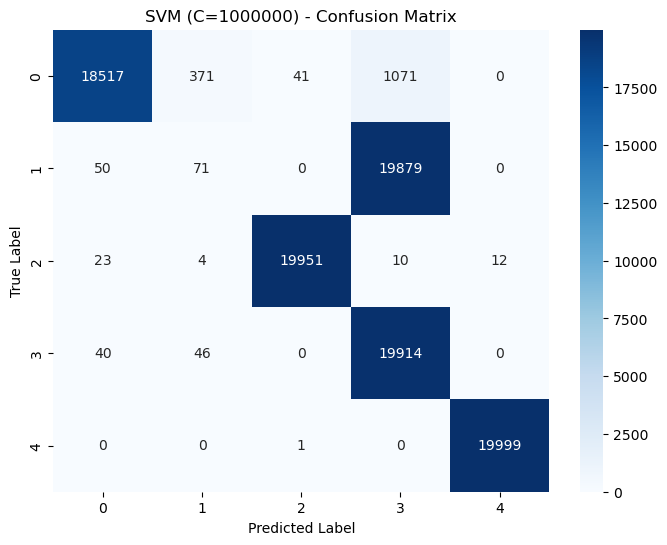


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96     20000
           1       0.14      0.00      0.01     20000
           2       1.00      1.00      1.00     20000
           3       0.49      1.00      0.65     20000
           4       1.00      1.00      1.00     20000

    accuracy                           0.78    100000
   macro avg       0.72      0.78      0.72    100000
weighted avg       0.72      0.78      0.72    100000



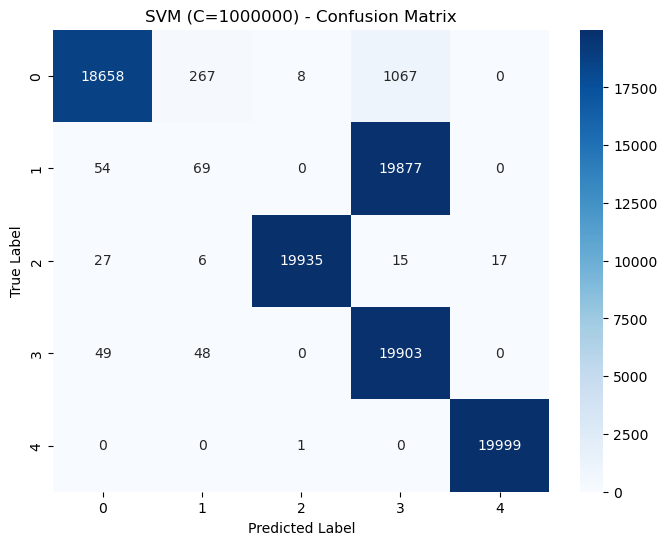


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96     20000
           1       0.18      0.00      0.01     20000
           2       1.00      1.00      1.00     20000
           3       0.49      1.00      0.65     20000
           4       1.00      1.00      1.00     20000

    accuracy                           0.79    100000
   macro avg       0.73      0.79      0.72    100000
weighted avg       0.73      0.79      0.72    100000

+----------------+------------+---------------+---------------+------------+
|   Chunk Number |   Accuracy |   Sensitivity |   Specificity |   F1 Score |
+================+============+===============+===============+============+
|             10 |    0.7836  |       0.7836  |      0.955668 |   0.722579 |
+----------------+------------+---------------+---------------+------------+
|             20 |    0.78452 |       0.78452 |      0.955884 |   0.723457 |
+----------------+------

In [8]:
results = []

# Run experiments for different chunk numbers
for chunk_num in [10, 20, 40]:
    metrics = map_reduce_svm(chunk_num=chunk_num, X_train_scaled=X_train_scaled, 
                             y_train=y_train, X_test_scaled=X_test_scaled, y_test=y_test)
    
    # Unpack metrics and store in list
    results.append([chunk_num, metrics["Accuracy"], metrics["Sensitivity"], metrics["Specificity"], metrics["F1 Score"]])

# Define table headers
headers = ["Chunk Number", "Accuracy", "Sensitivity", "Specificity", "F1 Score"]

# Print results in table format
print(tabulate(results, headers=headers, tablefmt="grid"))


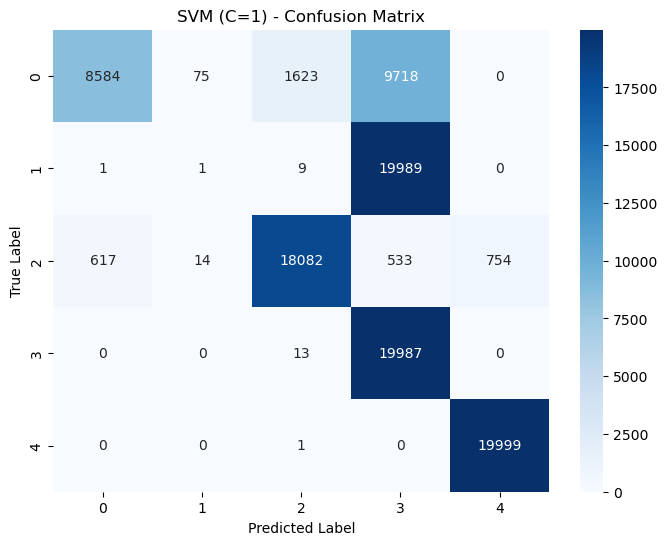


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.43      0.59     20000
           1       0.01      0.00      0.00     20000
           2       0.92      0.90      0.91     20000
           3       0.40      1.00      0.57     20000
           4       0.96      1.00      0.98     20000

    accuracy                           0.67    100000
   macro avg       0.64      0.67      0.61    100000
weighted avg       0.64      0.67      0.61    100000



In [ ]:
results = []

for constnat in [1,10,100,1000,10000,100000,1000000]:
    metrics = map_reduce_svm(chunk_num=10, X_train_scaled=X_train_scaled, y_train=y_train, 
                   X_test_scaled=X_test_scaled, y_test=y_test, C_constant=constnat)
    
    # Unpack metrics and store in list
    results.append([chunk_num, metrics["Accuracy"], metrics["Sensitivity"], metrics["Specificity"], metrics["F1 Score"]])
    
# Define table headers
headers = ["Chunk Number", "Accuracy", "Sensitivity", "Specificity", "F1 Score"]

# Print results in table format
print(tabulate(results, headers=headers, tablefmt="fancy_grid"))